In [20]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
dataset, info = tfds.load("cats_vs_dogs", with_info= True, as_supervised=True)

In [22]:
class_names = info.features["label"].names
class_names

['cat', 'dog']

In [23]:
for i, example in enumerate(dataset["train"]):

    image, label = example

    save_dir = "./cats_vs_dogs/train/{}".format(class_names[label])

    os.makedirs(save_dir, exist_ok=True)

    filename = save_dir + "/" + "{}_{}.jpg".format(class_names[label], i)

    tf.keras.preprocessing.image.save_img(filename, image.numpy())

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

In [29]:
datagen = ImageDataGenerator(rescale = 1/255, validation_split = 0.2, rotation_range = 10, 
                            width_shift_range = 0.1, height_shift_range = 0.1,
                            shear_range = 0.1, zoom_range = 0.10, horizontal_flip = True)


train_generator = datagen.flow_from_directory(
    "cats_vs_dogs/train",
    target_size=(150,150),
    batch_size=216,
    class_mode="binary",
    subset="training"
)

validation_generator = datagen.flow_from_directory(
    "cats_vs_dogs/train",
    target_size=(150,150),
    batch_size=216,
    class_mode="binary",
    subset="validation"
)

Found 18612 images belonging to 2 classes.
Found 4652 images belonging to 2 classes.


In [30]:
model = Sequential()

model.add(Conv2D(32, kernel_size=3, activation="relu", input_shape=(150,150,3)))
model.add(MaxPooling2D(2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=3, activation="relu"))
model.add(MaxPooling2D(2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv2D(128, kernel_size=3, activation="relu"))
model.add(MaxPooling2D(2))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add((Flatten()))
model.add(Dropout(0.5))
model.add(Dense(512, activation= "relu"))
model.add(Dense(1 , activation="sigmoid"))
          

In [31]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 batch_normalization_9 (Batc  (None, 74, 74, 32)       128       
 hNormalization)                                                 
                                                                 
 dropout_11 (Dropout)        (None, 74, 74, 32)        0         
                                                                 
 conv2d_10 (Conv2D)          (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 36, 36, 64)      

In [33]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam", metrics=["accuracy"]
)
history = model.fit(
    train_generator, epochs=15, validation_data=validation_generator
)

Epoch 1/15
87/87 [==============================] - 223s 3s/step - loss: 1.8132 - accuracy: 0.6370 - val_loss: 1.8061 - val_accuracy: 0.5013
Epoch 2/15
87/87 [==============================] - 218s 2s/step - loss: 0.6199 - accuracy: 0.7108 - val_loss: 3.6175 - val_accuracy: 0.5013
Epoch 3/15
87/87 [==============================] - 220s 3s/step - loss: 0.4991 - accuracy: 0.7571 - val_loss: 2.8558 - val_accuracy: 0.5013
Epoch 4/15
87/87 [==============================] - 228s 3s/step - loss: 0.4595 - accuracy: 0.7829 - val_loss: 3.5943 - val_accuracy: 0.5015
Epoch 5/15
87/87 [==============================] - 238s 3s/step - loss: 0.4459 - accuracy: 0.7900 - val_loss: 1.9863 - val_accuracy: 0.5075
Epoch 6/15
87/87 [==============================] - 241s 3s/step - loss: 0.4346 - accuracy: 0.7963 - val_loss: 1.8495 - val_accuracy: 0.5507
Epoch 7/15
87/87 [==============================] - 215s 2s/step - loss: 0.4216 - accuracy: 0.8036 - val_loss: 0.6038 - val_accuracy: 0.7199
Epoch 8/15
87

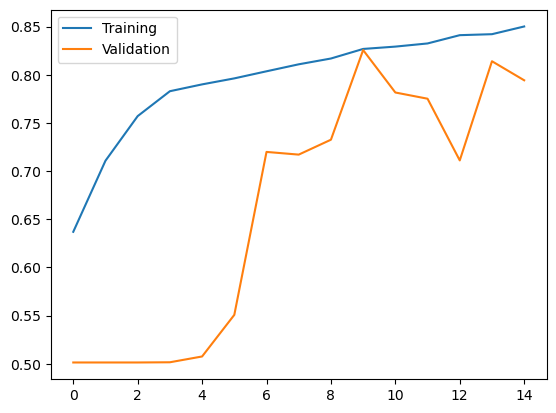

In [40]:
history.history
plt.plot(history.history["accuracy"], label = "Training")
plt.plot(history.history["val_accuracy"], label = "Validation")
plt.legend()
plt.show()

In [41]:
model.save("cats_vs_dogs.h5")

In [43]:
import requests
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np

img_url = "https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg"

img = Image.open(
    requests.get(img_url, stream=True).raw
).resize((150,150))

image_array = image.img_to_array(img)

img = np.expand_dims(image_array, axis=0)

img = img / 255

prediction = model.predict(img)

print(prediction)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 [==============================] - 0s 48ms/step
[[0.9749978]]
Dog
